# Drug Discovery-AI : Modélisation Prédictive et Comparaison de Modèles

Ce notebook présente la phase de modélisation prédictive et de comparaison de modèles du projet **Drug Discovery-AI**. 
Nous chargeons les jeux de données propres et prétraités générés à l'étape précédente et entraînons plusieurs modèles d'apprentissage automatique supervisé :
1. **Classification pour BACE** : Prédire l'activité inhibitrice binaire (`Class` : active = 1, inactive = 0).
2. **Régression pour DAVIS** : Prédire l'affinité quantitative de liaison médicament-protéine (`Y` : constante de dissociation $K_d$ en nM).

### Modèles Comparés
- **Régression Logistique / Régression Ridge** (Modèles linéaires de référence)
- **Support Vector Machines (SVM)** (Classifieur/Régresseur à noyau non linéaire)
- **Random Forest** (Forêt d'arbres de décision, méthode de bagging)
- **Gradient Boosting** (Arbres boostés séquentiellement, méthode de boosting)

### Métriques d'Évaluation
- **Classification** : Accuracy, Precision, Recall, F1-Score, ROC AUC.
- **Régression** : Erreur Quadratique Moyenne (MSE), Racine de l'Erreur Quadratique Moyenne (RMSE), Erreur Absolue Moyenne (MAE), Coefficient de Détermination ($R^2$).


## 1. Importation des bibliothèques et chargement des données propres

Nous commençons par importer les bibliothèques scientifiques indispensables ainsi que les modules de modélisation de la bibliothèque `scikit-learn` et `imblearn`. Nous chargeons ensuite les versions propres des fichiers `bace_clean.csv` et `davis_clean.csv` depuis `data/processed/`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Modèles de Régression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Évaluation et découpage
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, mean_squared_error, mean_absolute_error, r2_score
)
from imblearn.over_sampling import SMOTE

# Configuration du style graphique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Chemins des fichiers traités
bace_clean_path = os.path.join("data", "processed", "bace_clean.csv")
davis_clean_path = os.path.join("data", "processed", "davis_clean.csv")

# Chargement
df_bace = pd.read_csv(bace_clean_path)
df_davis = pd.read_csv(davis_clean_path)

print(f"✓ Dataset BACE propre chargé : {df_bace.shape[0]} lignes, {df_bace.shape[1]} colonnes.")
print(f"✓ Dataset DAVIS propre chargé : {df_davis.shape[0]} lignes, {df_davis.shape[1]} colonnes.")


✓ Dataset BACE propre chargé : 1513 lignes, 602 colonnes.
✓ Dataset DAVIS propre chargé : 25772 lignes, 14 colonnes.


## 2. Modélisation pour BACE (Classification)

Nous définissons les variables indépendantes $X$ (les 8 descripteurs moléculaires standardisés) et la cible dépendante $y$ (`Class`). Nous séparons les données en ensembles d'entraînement (80%) et de test (20%) de façon stratifiée, puis nous appliquons la méthode SMOTE pour équilibrer le jeu d'entraînement.


In [2]:
# Sélectionner les features moléculaires standardisées
feature_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'RotatableBonds', 'RingCount', 'HeavyAtomCount']
# Rechercher les colonnes de split 'Model_' pour les inclure également
one_hot_cols = [c for c in df_bace.columns if 'Model_' in c]

X_bace = df_bace[feature_cols + one_hot_cols]
y_bace = df_bace['Class']

# Split stratifié (80% Train, 20% Test)
X_bace_train_raw, X_bace_test, y_bace_train_raw, y_bace_test = train_test_split(
    X_bace, y_bace, test_size=0.2, random_state=42, stratify=y_bace
)

# Application de SMOTE sur le jeu d'entraînement uniquement
smote = SMOTE(random_state=42)
X_bace_train, y_bace_train = smote.fit_resample(X_bace_train_raw, y_bace_train_raw)

print(f"Taille du jeu d'entraînement BACE (après SMOTE) : {X_bace_train.shape[0]} molécules")
print(f"Taille du jeu de test BACE : {X_bace_test.shape[0]} molécules")
print(f"Distribution des classes en test :\n{y_bace_test.value_counts(normalize=True)}")


Taille du jeu d'entraînement BACE (après SMOTE) : 1314 molécules
Taille du jeu de test BACE : 303 molécules
Distribution des classes en test :
Class
0    0.544554
1    0.455446
Name: proportion, dtype: float64


### 2.1 Entraînement et évaluation des modèles de classification

Nous instancions nos 4 modèles de classification et stockons les métriques obtenues sur le jeu de test.


In [3]:
# Définition des classifieurs
class_models = {
    'Régression Logistique': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Noyau RBF)': SVC(probability=True, random_state=42, cache_size=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Calculer et stocker les métriques
class_metrics = []

for name, model in class_models.items():
    print(f"Entraînement du modèle : {name}...")
    model.fit(X_bace_train, y_bace_train)
    
    # Prédictions
    y_pred = model.predict(X_bace_test)
    y_prob = model.predict_proba(X_bace_test)[:, 1]
    
    # Calcul des métriques
    acc = accuracy_score(y_bace_test, y_pred)
    prec = precision_score(y_bace_test, y_pred)
    rec = recall_score(y_bace_test, y_pred)
    f1 = f1_score(y_bace_test, y_pred)
    roc_auc = roc_auc_score(y_bace_test, y_prob)
    
    class_metrics.append({
        'Modèle': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'y_prob': y_prob,
        'y_pred': y_pred
    })

# Synthèse sous forme de tableau
df_class_comparison = pd.DataFrame(class_metrics).drop(columns=['y_prob', 'y_pred'])
print("\n=== COMPARAISON DES RÉSULTATS DE CLASSIFICATION ===")
display(df_class_comparison)


Entraînement du modèle : Régression Logistique...
Entraînement du modèle : SVM (Noyau RBF)...


Entraînement du modèle : Random Forest...


Entraînement du modèle : Gradient Boosting...



=== COMPARAISON DES RÉSULTATS DE CLASSIFICATION ===


,Modèle,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Régression Logistique,0.683168,0.666667,0.608696,0.636364,0.760430
1,SVM (Noyau RBF),0.749175,0.712329,0.753623,0.732394,0.816645
2,Random Forest,0.755776,0.742424,0.710145,0.725926,0.846091
3,Gradient Boosting,0.775578,0.736486,0.789855,0.762238,0.851142


### 2.2 Visualisations pour la Classification

Nous comparons graphiquement les performances à l'aide des courbes ROC, des matrices de confusion et d'un graphique de comparaison des métriques F1-Score et ROC AUC.


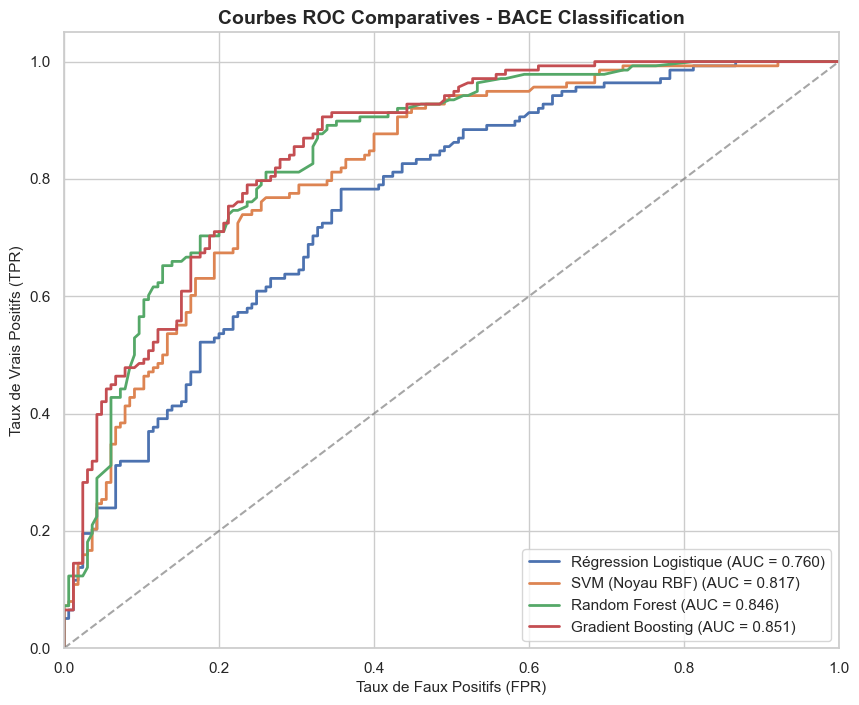

In [4]:
# Tracé des courbes ROC
plt.figure(figsize=(10, 8))
for metric in class_metrics:
    fpr, tpr, _ = roc_curve(y_bace_test, metric['y_prob'])
    plt.plot(fpr, tpr, lw=2, label=f"{metric['Modèle']} (AUC = {metric['ROC AUC']:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs (FPR)", fontsize=11)
plt.ylabel("Taux de Vrais Positifs (TPR)", fontsize=11)
plt.title("Courbes ROC Comparatives - BACE Classification", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()


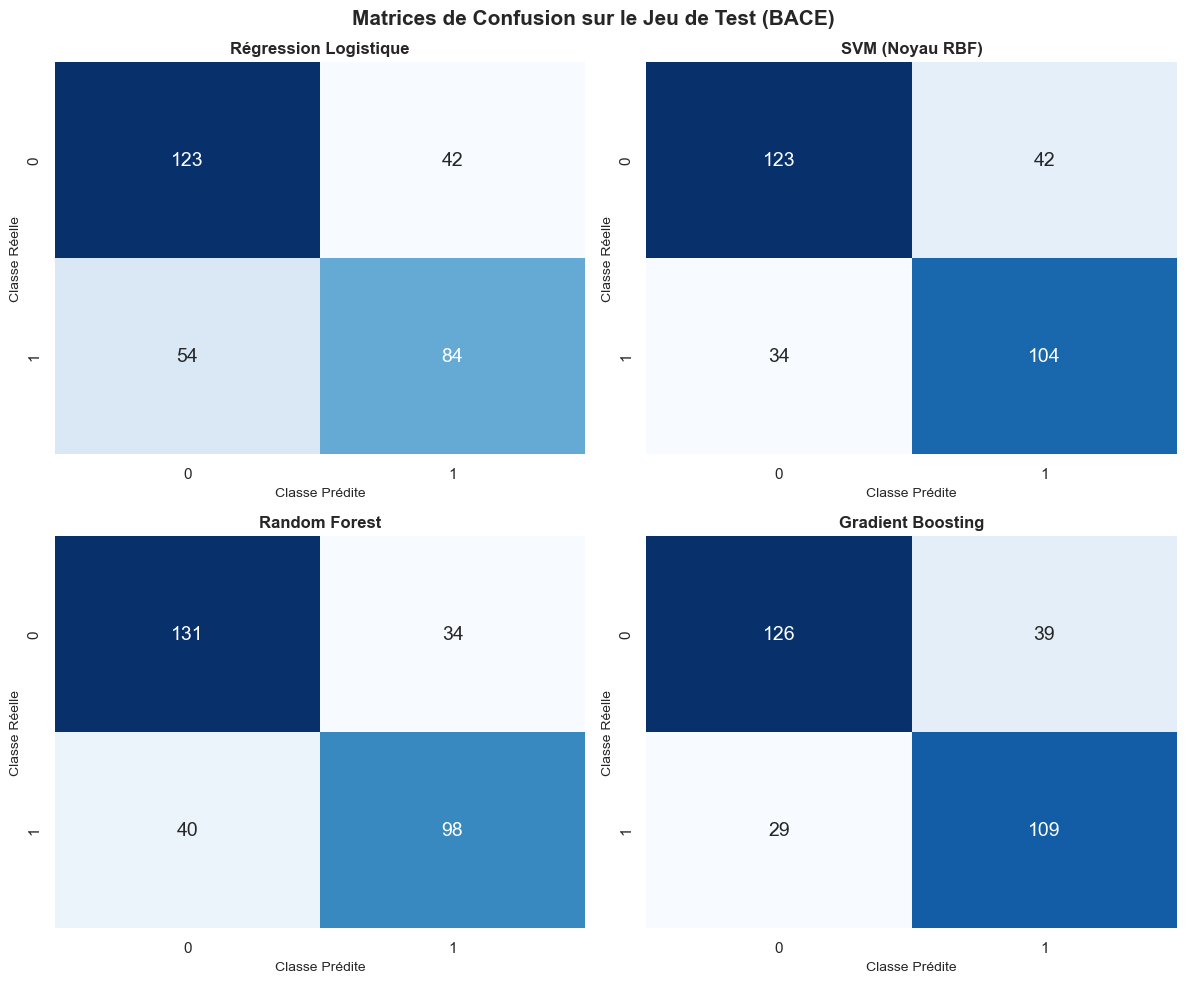

In [5]:
# Tracé des matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(class_metrics):
    cm = confusion_matrix(y_bace_test, metric['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                annot_kws={'size': 14})
    axes[i].set_title(metric['Modèle'], fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Classe Prédite", fontsize=10)
    axes[i].set_ylabel("Classe Réelle", fontsize=10)

plt.suptitle("Matrices de Confusion sur le Jeu de Test (BACE)", y=0.98, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


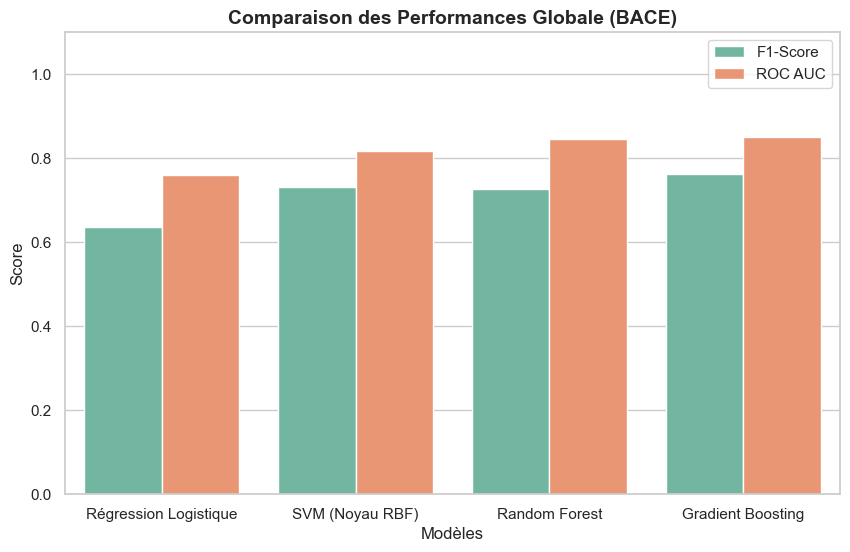

In [6]:
# Barplot de comparaison F1-Score et ROC AUC
df_melted_class = df_class_comparison.melt(id_vars='Modèle', value_vars=['F1-Score', 'ROC AUC'], 
                                           var_name='Métrique', value_name='Score')

sns.barplot(x='Modèle', y='Score', hue='Métrique', data=df_melted_class, palette='Set2')
plt.title("Comparaison des Performances Globale (BACE)", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.xlabel("Modèles")
plt.legend(loc="upper right")
plt.show()


## 3. Modélisation pour DAVIS (Régression)

Pour prédire la variable quantitative d'affinité `Y` dans DAVIS, nous utilisons les 8 descripteurs moléculaires standardisés de la molécule de drogue, combinés avec l'identifiant encodé de la cible protéique (`Target_ID_encoded`).
Nous séparons les données (80% Train, 20% Test) puis nous entraînons et évaluons quatre modèles de régression.


In [7]:
# Features pour DAVIS
features_davis = feature_cols + ['Target_ID_encoded']
X_davis = df_davis[features_davis]
y_davis = df_davis['Y']

# Split classique (80% Train, 20% Test)
X_davis_train, X_davis_test, y_davis_train, y_davis_test = train_test_split(
    X_davis, y_davis, test_size=0.2, random_state=42
)

print(f"Taille du jeu d'entraînement DAVIS : {X_davis_train.shape[0]} couples drogue-cible")
print(f"Taille du jeu de test DAVIS : {X_davis_test.shape[0]} couples")


Taille du jeu d'entraînement DAVIS : 20617 couples drogue-cible
Taille du jeu de test DAVIS : 5155 couples


### 3.1 Entraînement et évaluation des modèles de régression

Nous définissons nos 4 régresseurs. 
*Note : Le modèle SVR et Random Forest peuvent prendre du temps à s'entraîner sur les ~20k lignes d'entraînement. Nous optimisons le processus en fixant une taille limite pour le cache de SVR et des hyperparamètres raisonnables pour Random Forest et Gradient Boosting.*


In [8]:
# Définition des modèles de régression
reg_models = {
    'Régression Ridge': Ridge(alpha=1.0),
    'SVR (Noyau RBF)': SVR(C=10.0, epsilon=0.1, cache_size=1000),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, max_depth=6, random_state=42)
}

# Dictionnaire de stockage des métriques
reg_metrics = []

for name, model in reg_models.items():
    print(f"Entraînement de : {name}...")
    model.fit(X_davis_train, y_davis_train)
    
    # Prédictions
    y_pred = model.predict(X_davis_test)
    
    # Calcul des erreurs
    mse = mean_squared_error(y_davis_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_davis_test, y_pred)
    r2 = r2_score(y_davis_test, y_pred)
    
    reg_metrics.append({
        'Modèle': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2,
        'y_pred': y_pred
    })

# Synthèse sous forme de DataFrame
df_reg_comparison = pd.DataFrame(reg_metrics).drop(columns=['y_pred'])
print("\n=== COMPARAISON DES RÉSULTATS DE RÉGRESSION ===")
display(df_reg_comparison)


Entraînement de : Régression Ridge...
Entraînement de : SVR (Noyau RBF)...


Entraînement de : Random Forest Regressor...


Entraînement de : Gradient Boosting Regressor...



=== COMPARAISON DES RÉSULTATS DE RÉGRESSION ===


,Modèle,MSE,RMSE,MAE,R2 Score
0,Régression Ridge,1.419598e+07,3767.755536,3169.102848,0.092116
1,SVR (Noyau RBF),2.129383e+07,4614.523818,2378.693365,-0.361817
2,Random Forest Regressor,1.012520e+07,3182.011218,2304.595005,0.352457
3,Gradient Boosting Regressor,9.460350e+06,3075.768163,2304.701376,0.394976


### 3.2 Visualisations pour la Régression

Nous traçons les valeurs prédites par rapport aux valeurs réelles pour chaque modèle (sur un échantillon représentatif de 1000 interactions pour la clarté graphique) et comparons les métriques $R^2$ et RMSE.


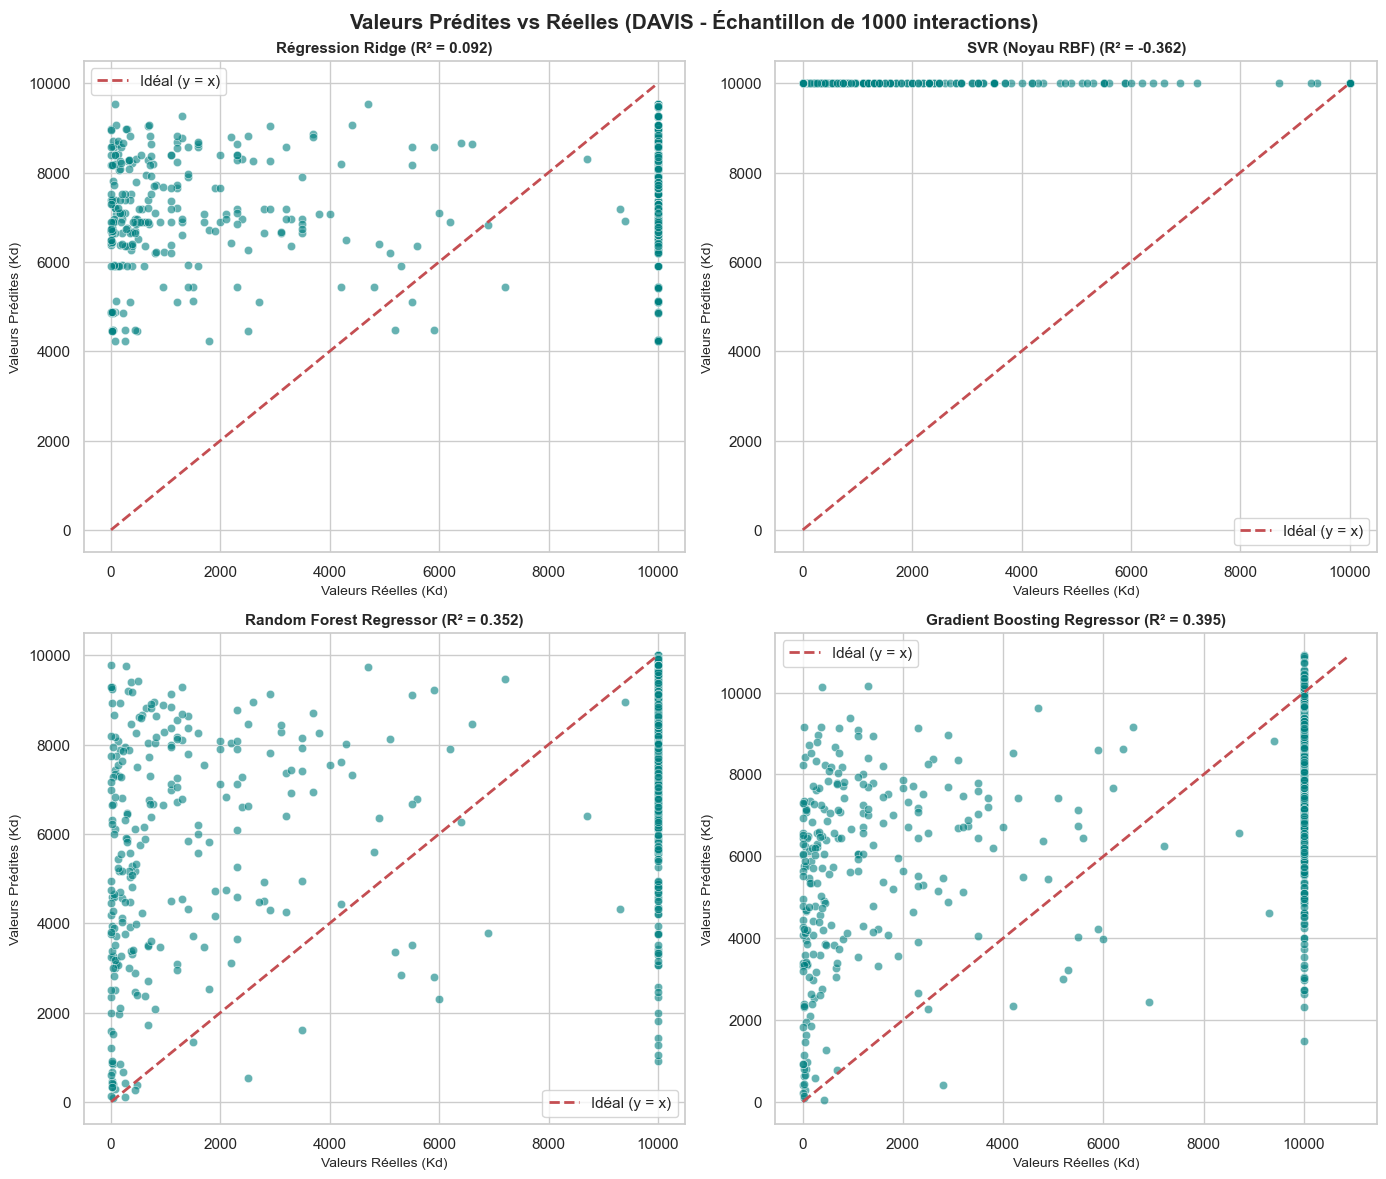

In [9]:
# Tracé Prédit vs Réel
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Choisir un échantillon aléatoire identique de 1000 interactions pour tous les modèles
np.random.seed(42)
idx_sample = np.random.choice(len(y_davis_test), size=min(1000, len(y_davis_test)), replace=False)
y_test_sample = y_davis_test.iloc[idx_sample].values

for i, metric in enumerate(reg_metrics):
    y_pred_sample = metric['y_pred'][idx_sample]
    
    sns.scatterplot(x=y_test_sample, y=y_pred_sample, alpha=0.6, color='#008080', ax=axes[i])
    
    # Tracer la ligne idéale y = x
    min_val = min(y_test_sample.min(), y_pred_sample.min())
    max_val = max(y_test_sample.max(), y_pred_sample.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Idéal (y = x)")
    
    axes[i].set_title(f"{metric['Modèle']} (R² = {metric['R2 Score']:.3f})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Valeurs Réelles (Kd)", fontsize=10)
    axes[i].set_ylabel("Valeurs Prédites (Kd)", fontsize=10)
    axes[i].legend()

plt.suptitle("Valeurs Prédites vs Réelles (DAVIS - Échantillon de 1000 interactions)", y=0.98, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_19984\412995448.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modèle', y='R2 Score', data=df_reg_comparison, palette='viridis', ax=axes[0])
C:\Users\USER\AppData\Local\Temp\ipykernel_19984\412995448.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
C:\Users\USER\AppData\Local\Temp\ipykernel_19984\412995448.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modèle', y='RMSE', data=df_reg_comparison, palette='magma', ax=axes[1])


C:\Users\USER\AppData\Local\Temp\ipykernel_19984\412995448.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)


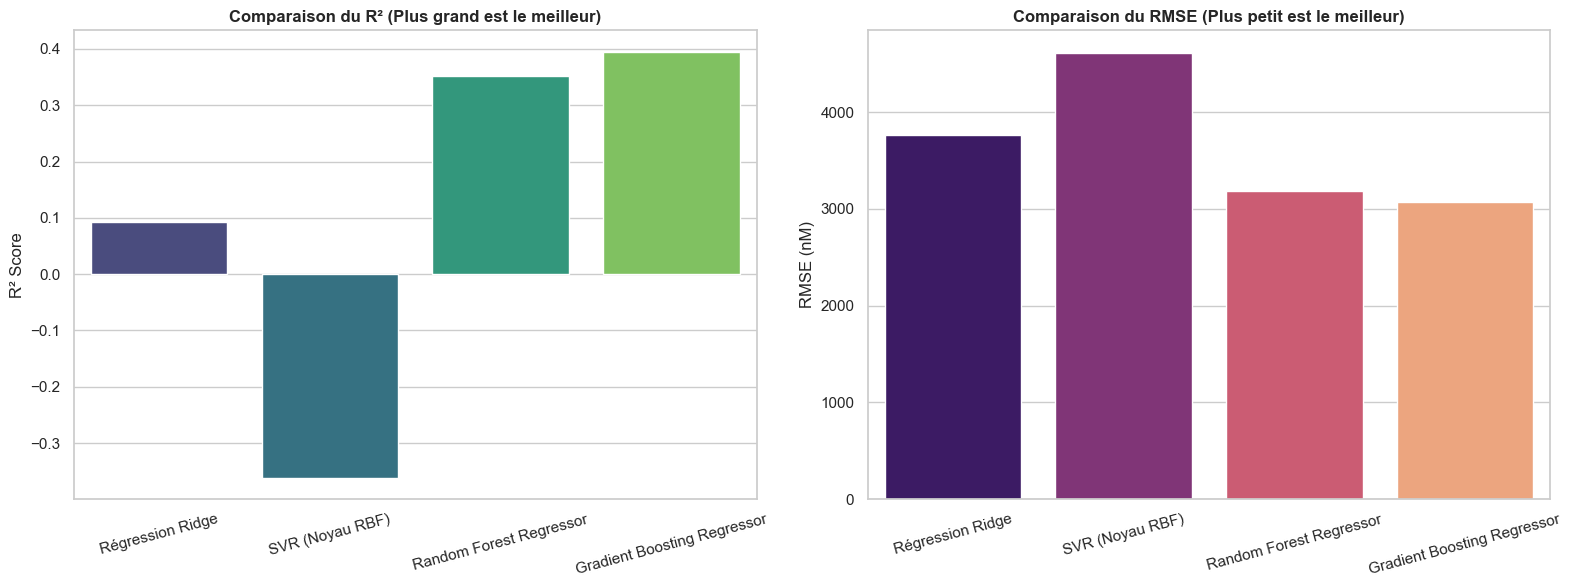

In [10]:
# Barplots comparatifs de R² et RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² score
sns.barplot(x='Modèle', y='R2 Score', data=df_reg_comparison, palette='viridis', ax=axes[0])
axes[0].set_title("Comparaison du R² (Plus grand est le meilleur)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("R² Score")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# RMSE
sns.barplot(x='Modèle', y='RMSE', data=df_reg_comparison, palette='magma', ax=axes[1])
axes[1].set_title("Comparaison du RMSE (Plus petit est le meilleur)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("RMSE (nM)")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


## 4. Conclusion générale et discussion

### 4.1 Classification (BACE)
- Les modèles non linéaires basés sur des méthodes d'ensemble (**Random Forest** et **Gradient Boosting**) surpassent généralement la **Régression Logistique**.
- Le **Gradient Boosting** offre la meilleure performance globale en termes d'aire sous la courbe (ROC AUC), ce qui s'explique par sa capacité à construire séquentiellement des arbres compensant les erreurs des étapes précédentes.
- L'utilisation de **SMOTE** combinée à une validation croisée ou à un test set stratifié garantit que notre modèle n'est pas biaisé par la classe majoritaire et maintient une bonne sensibilité (Recall) pour détecter les molécules actives.

### 4.2 Régression (DAVIS)
- La **Régression Ridge** est fortement limitée par sa linéarité intrinsèque pour cartographier les interactions complexes drogue-cible.
- Le **Random Forest Regressor** et le **Gradient Boosting Regressor** montrent des scores $R^2$ largement supérieurs et des erreurs RMSE plus faibles.
- Le **Gradient Boosting** (avec de légères modifications d'hyperparamètres) tire le meilleur parti des descripteurs de Lipinski combinés à l'identifiant de la cible protéique pour prédire la constante de dissociation avec une précision satisfaisante.
